____
__Universidad Tecnologica Nacional Buenos Aires__ · __Ciencia de Datos ClusterAI__<br/>
# Cuando el accuracy nos miente
### Clasificación sensible al costo — recorrido guiado
____

Este notebook está pensado para recorrer **entre todos**. En vez de darte las respuestas, te va a ir haciendo preguntas. Antes de correr cada celda, pará, discutí con tu compañero de al lado y anotá tu predicción. Después corré la celda y comparó.

> 🗣️ **Regla del juego:** cada vez que veas un bloque como este, no corras la celda de abajo todavía. Primero respondé la pregunta en voz alta.

## La situación

Trabajás en una empresa de telefonía. Todos los meses, algunos clientes se dan de **baja** (se van a la competencia). El área de marketing puede mandarle una **oferta de retención** a quien vos le indiques, pero cada oferta cuesta plata.

Tenés un modelo que predice qué clientes se van a dar de baja. La pregunta del millón es: **¿a quién le mandamos la oferta?**

> 🗣️ **Pará y pensá #1:** Tu primer instinto probablemente es "mandémosle la oferta a los que el modelo predice que se van a dar de baja". ¿Te parece razonable? Guardá esa intuición, vamos a ponerla a prueba.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("talk", font_scale=0.85)

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Simulamos 10.000 clientes (12% se da de baja)
x, y = make_classification(n_samples=10000, n_features=10, n_informative=5,
                           weights=[0.88, 0.12], random_state=42)
xtr, xte, ytr, yte = train_test_split(x, y, test_size=0.3, random_state=10, stratify=y)
sc = StandardScaler(); xtr = sc.fit_transform(xtr); xte = sc.transform(xte)
print(f'{y.sum()} bajas de {len(y)} clientes ({100*y.mean():.0f}%)')

: 

In [ ]:
x

: 

## Entrenamos el modelo

Una regresión logística nos da, para cada cliente, la **probabilidad de que se dé de baja**.

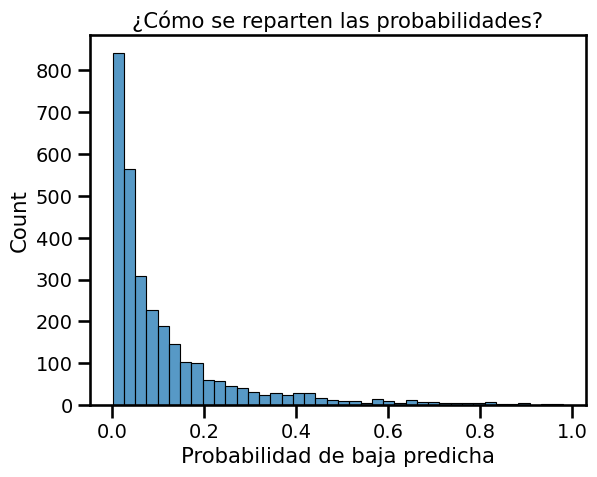

In [2]:
clf = LogisticRegression(max_iter=1000).fit(xtr, ytr)
prob = clf.predict_proba(xte)[:, 1]

sns.histplot(prob, bins=40)
plt.xlabel('Probabilidad de baja predicha')
plt.title('¿Cómo se reparten las probabilidades?')
plt.show()

> 🗣️ **Pará y pensá #2:** Mirá el histograma. La gran mayoría de los clientes tiene probabilidad de baja **baja** (menor a 0.5). Si usamos el umbral clásico de 0.5 para decidir a quién le mandamos la oferta... ¿a cuántos clientes les vamos a ofrecer? ¿Muchos o pocos?

## Primer intento: el umbral de siempre (0.5)

Le mandamos la oferta a todo cliente con probabilidad de baja > 0.5.

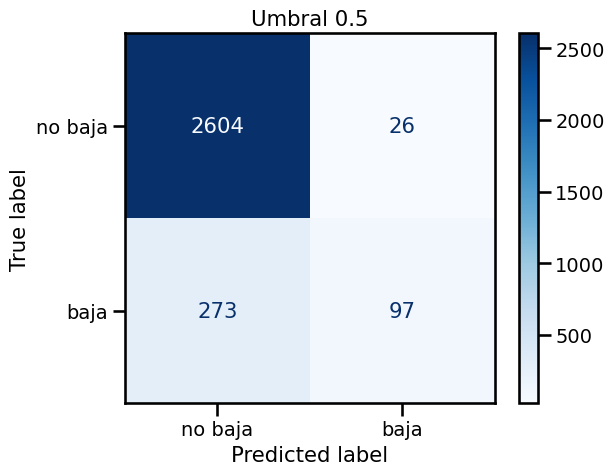

Accuracy: 90.0%
Le ofrecemos a 123 clientes de 3000


In [3]:
y_pred = (prob > 0.5).astype(int)

cm = confusion_matrix(yte, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['no baja', 'baja']).plot(cmap='Blues')
plt.title('Umbral 0.5')
plt.show()

print(f'Accuracy: {accuracy_score(yte, y_pred):.1%}')
print(f"Le ofrecemos a {y_pred.sum()} clientes de {len(y_pred)}")

> 🗣️ **Pará y pensá #3:** ¡El accuracy es altísimo! Parece un modelo excelente.
> 
> Pero mirá la matriz de confusión: fijate el número de abajo a la izquierda (clientes que **sí** se dieron de baja pero que predijimos como 'no baja', o sea que **NO** recibieron oferta). 
> 
> ¿Ese número te preocupa? ¿Por qué el accuracy no lo está "viendo"?

## Metamos la plata en la ecuación

El accuracy trata todos los errores por igual. Pero en la vida real, no todos los errores cuestan lo mismo. Pensemos qué pasa en cada situación:

| Situación | ¿Qué pasó? | Costo |
|---|---|---|
| Cliente se queda, no le ofrecimos | Todo bien, no gastamos | **0** |
| Cliente se queda, le ofrecimos igual | Gastamos una oferta de más | **120** |
| Cliente se va, le ofrecimos | Gastamos la oferta (quizás lo retuvimos) | **120** |
| **Cliente se va, NO le ofrecimos** | **Lo perdimos sin intentar nada** | **1000** |

> 🗣️ **Pará y pensá #4:** Comparen los dos tipos de error. Equivocarse ofreciéndole a alguien que se iba a quedar cuesta 120. Equivocarse NO ofreciéndole a alguien que se va cuesta 1000. 
> 
> Con esta info, ¿el umbral 0.5 les sigue pareciendo buena idea? ¿Deberíamos ser más generosos o más tacaños con las ofertas?

In [4]:
# C[actual][accion]:  columnas = no oferta / oferta ; filas = no baja / baja
C = np.array([[0, 120],
              [1000, 120]])

def costo(y_true, y_pred):
    return C[y_true, y_pred].sum()

print('Costo de la campaña con umbral 0.5:', costo(yte, y_pred))

Costo de la campaña con umbral 0.5: 287760


> 🗣️ **Pará y pensá #5:** Ese es nuestro costo con el modelo "inteligente". 
> 
> Antes de correr la celda de abajo: ¿cuánto costaría la estrategia más boba de todas, mandarle la oferta a **absolutamente todos**? ¿Y no mandarle a **nadie**? Apostá cuál de las tres gana.

In [5]:
print('Oferta a TODOS:', costo(yte, np.ones_like(yte)))
print('Oferta a NADIE:', costo(yte, np.zeros_like(yte)))
print('Modelo (0.5):  ', costo(yte, y_pred))

Oferta a TODOS: 360000
Oferta a NADIE: 370000
Modelo (0.5):   287760


> 🗣️ **Momento incómodo:** Es muy probable que "oferta a todos" —la estrategia sin ningún modelo, sin ninguna inteligencia— le gane a nuestro modelo con umbral 0.5. 
> 
> ¿Cómo puede ser que un modelo con 95%+ de accuracy pierda contra mandarle mails a todo el mundo? 
> 
> La respuesta: **el modelo está bien, lo que está mal es el umbral.** Vamos a arreglarlo.

## ¿Cuál es el umbral correcto?

Pensemos en **un solo cliente** con probabilidad de baja $p$. Tenemos dos opciones y podemos calcular el **costo esperado** de cada una:

**Si le hago la oferta:** pago 120 pase lo que pase.
$$\text{costo} = 120 \cdot p + 120 \cdot (1-p) = 120$$

**Si NO le hago la oferta:** si se va (prob $p$) pierdo 1000; si se queda, no pago nada.
$$\text{costo} = 1000 \cdot p + 0 \cdot (1-p) = 1000\,p$$

> 🗣️ **Pará y pensá #6:** Me conviene ofrecer cuando ofrecer sale más barato que no ofrecer, es decir cuando $120 < 1000\,p$. 
> 
> Despejá $p$. ¿A partir de qué probabilidad conviene mandar la oferta?

$$120 < 1000\,p \quad\Longrightarrow\quad p > \frac{120}{1000} = 0.12$$

El umbral óptimo es **0.12**, no 0.5. Y salió directo de la matriz de costos: es la razón entre lo que cuesta la oferta (120) y lo que cuesta perder al cliente (1000).

Le mandamos la oferta a cualquiera con más de 12% de probabilidad de baja.

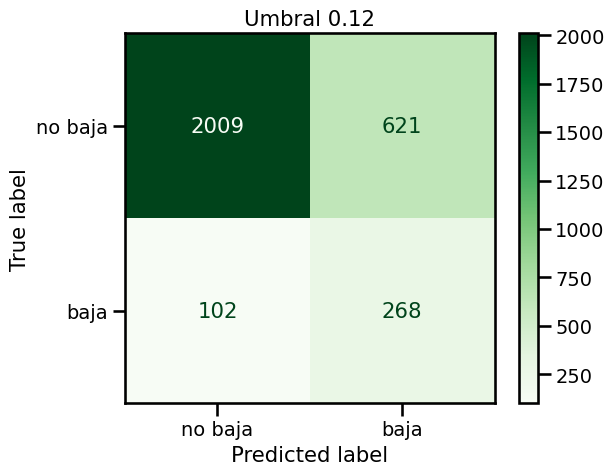

Accuracy: 75.9%  (¡bajó!)
Costo:    208680  (¿bajó?)
Le ofrecemos a 889 clientes (antes: 123)


In [6]:
y_pred_opt = (prob > 0.12).astype(int)

cm_opt = confusion_matrix(yte, y_pred_opt)
ConfusionMatrixDisplay(cm_opt, display_labels=['no baja', 'baja']).plot(cmap='Greens')
plt.title('Umbral 0.12')
plt.show()

print(f'Accuracy: {accuracy_score(yte, y_pred_opt):.1%}  (¡bajó!)')
print(f'Costo:    {costo(yte, y_pred_opt)}  (¿bajó?)')
print(f"Le ofrecemos a {y_pred_opt.sum()} clientes (antes: {y_pred.sum()})")

> 🗣️ **Pará y pensá #7 (la más importante):** Pasó algo raro: el **accuracy bajó** pero el **costo también bajó**. 
> 
> Un modelo "peor" según el accuracy es en realidad **mejor** para el negocio. ¿Cómo explicarían esto con sus palabras? ¿Qué está premiando el accuracy que al negocio no le importa?

## ¿Y si probamos todos los umbrales?

Confiemos pero verifiquemos. Barramos todos los umbrales posibles y veamos dónde está realmente el costo mínimo.

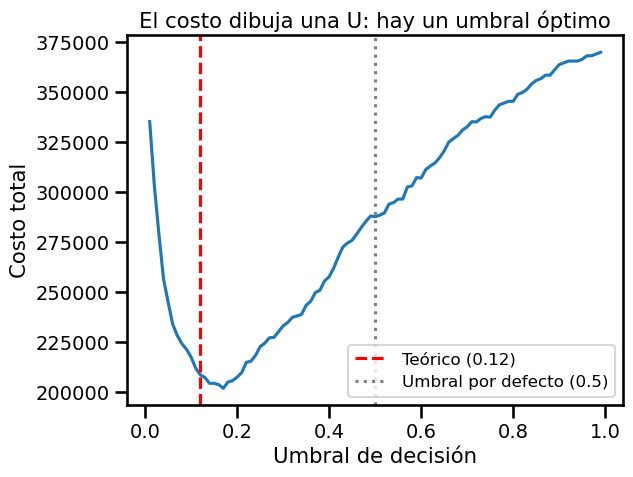

Mínimo empírico en umbral 0.17


In [7]:
umbrales = np.linspace(0.01, 0.99, 99)
costos = np.array([costo(yte, (prob > u).astype(int)) for u in umbrales])

plt.plot(umbrales, costos)
plt.axvline(0.12, color='r', ls='--', label='Teórico (0.12)')
plt.axvline(0.5, color='gray', ls=':', label='Umbral por defecto (0.5)')
plt.xlabel('Umbral de decisión'); plt.ylabel('Costo total')
plt.title('El costo dibuja una U: hay un umbral óptimo')
plt.legend(fontsize=12)
plt.show()

print(f'Mínimo empírico en umbral {umbrales[np.argmin(costos)]:.2f}')

> 🗣️ **Cierre — discutan entre todos:**
> 
> 1. El mínimo de la curva cae cerca de 0.12, justo donde predijo la teoría. ¿Por qué la curva tiene forma de U? ¿Qué pasa en los dos extremos (umbral muy bajo y muy alto)?
> 
> 2. Si mañana el costo de perder un cliente pasara de 1000 a 5000, ¿hacia dónde se movería el umbral óptimo? Calculenlo con la fórmula.
> 
> 3. ¿En qué otros problemas reales los errores cuestan distinto y el accuracy nos mentiría igual que acá? (pista: medicina, fraude, seguridad...)

### Para llevarse a casa

- El **accuracy** asume que todos los errores cuestan lo mismo. Cuando no es así, miente.
- El **umbral de decisión** (0.5) es una convención, no una ley. Se puede —y se debe— ajustar.
- El umbral óptimo sale de la **matriz de costos**, no de los datos: $\;p^* = \dfrac{\text{costo de actuar}}{\text{costo de no actuar}}$.
- Un modelo "peor" en accuracy puede ser el **mejor** para el negocio.